<a href="https://colab.research.google.com/github/Kamali1265/ML-Ops-Tasks/blob/main/DAY-6/knn_classification_traffic_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h2 style='color:blue' align="center">KNN (K Nearest Neighbors) Classification</h2>

In [1]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv("traffic_knn_dataset.csv")
df.head()

,vehicle_count,avg_speed,signal_wait_time,peak_hour,congestion_level
0,377,29,8,1,Medium
1,175,43,22,0,Low
2,396,26,80,1,High
3,66,18,16,0,Low
4,169,79,82,0,Low


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   vehicle_count     120 non-null    int64 
 1   avg_speed         120 non-null    int64 
 2   signal_wait_time  120 non-null    int64 
 3   peak_hour         120 non-null    int64 
 4   congestion_level  120 non-null    object
dtypes: int64(4), object(1)
memory usage: 4.8+ KB


In [5]:
df['congestion_level'].value_counts()

,count
congestion_level,
Medium,62
Low,37
High,21


In [6]:
df['congestion_level'] = df['congestion_level'].map({
    'Low':0,
    'Medium':1,
    'High':2
})

df.head()

,vehicle_count,avg_speed,signal_wait_time,peak_hour,congestion_level
0,377,29,8,1,1
1,175,43,22,0,0
2,396,26,80,1,2
3,66,18,16,0,0
4,169,79,82,0,0


In [7]:
X = df.drop('congestion_level', axis='columns')
y = df['congestion_level']

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [10]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

KNeighborsClassifier()

In [11]:
knn.score(X_test, y_test)

0.8333333333333334

In [12]:
y_pred = knn.predict(X_test)

y_pred

array([0, 2, 1, 1, 0, 1, 1, 1, 0, 2, 0, 1, 1, 1, 0, 0, 2, 1, 1, 0, 1, 0,
       1, 0])

In [13]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

cm

array([[ 8,  2,  0],
       [ 1, 10,  1],
       [ 0,  0,  2]])

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

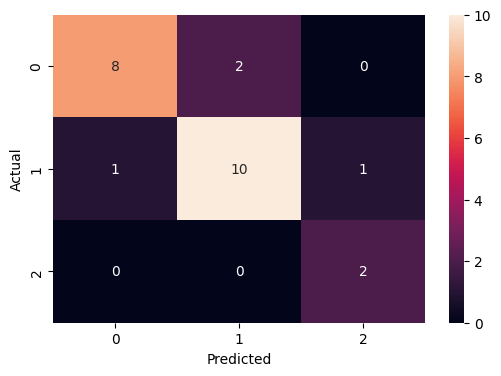

In [15]:
plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [16]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.80      0.84        10
           1       0.83      0.83      0.83        12
           2       0.67      1.00      0.80         2

    accuracy                           0.83        24
   macro avg       0.80      0.88      0.83        24
weighted avg       0.84      0.83      0.83        24



In [17]:
scores = []

for k in range(1,16):
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train,y_train)

    scores.append(
        model.score(X_test,y_test)
    )

for i in range(1,16):
    print(
        "K =",i,
        " Accuracy =",scores[i-1]
    )

K = 1  Accuracy = 0.9166666666666666
K = 2  Accuracy = 0.875
K = 3  Accuracy = 0.8333333333333334
K = 4  Accuracy = 0.8333333333333334
K = 5  Accuracy = 0.8333333333333334
K = 6  Accuracy = 0.8333333333333334
K = 7  Accuracy = 0.7916666666666666
K = 8  Accuracy = 0.875
K = 9  Accuracy = 0.875
K = 10  Accuracy = 0.8333333333333334
K = 11  Accuracy = 0.875
K = 12  Accuracy = 0.875
K = 13  Accuracy = 0.875
K = 14  Accuracy = 0.875
K = 15  Accuracy = 0.7916666666666666


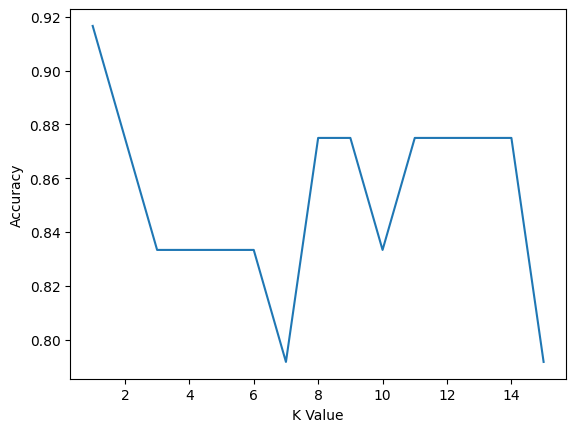

In [18]:
plt.plot(range(1,16),scores)
plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.show()

In [19]:
best_knn = KNeighborsClassifier(
    n_neighbors=3
)

best_knn.fit(X_train,y_train)

best_knn.score(X_test,y_test)

0.8333333333333334

In [20]:
best_knn.predict(
    scaler.transform([
        [300,30,45,1]
    ])
)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([1])